# Causal Intervention vs Observational Study

**Companion to** [research/04-causal-intervention-vs-observational.md](../research/04-causal-intervention-vs-observational.md)

A probe measures *correlation* — $P(Y\mid Z)$, "the concept is decodable from the latent". Causation
needs the **interventional** distribution $P(Y\mid do(Z=z))$: directly *edit* the representation and
watch the output move. The gap between the two is **confounding**, and in a latent space we can run
$do(\cdot)$ exactly — by surgery on the activation vector $z' = z - (w_C^\top z)\,w_C + v\,w_C$.

**What we will see:**
1. Confounding: a strong observational correlation that vanishes under intervention.
2. A feature can be **decodable but unused** — high probe accuracy, zero causal effect.
3. The latent $do$-operator: erasing vs steering a concept direction, and its causal response curve.
4. Amnesic probing — erase a concept and measure the behavioural drop (used vs unused concept).
5. The limit: pushing an intervention **off-manifold** turns the "effect" into an artifact.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


## Experiment 1: Confounding — correlation that dies under intervention

**Question:** Why isn't $P(Y\mid X)$ enough to claim $X$ causes $Y$?

The textbook trap: ice-cream sales $X$ and drownings $Y$ correlate strongly, but neither causes the
other — a hidden confounder $C$ (summer heat) drives both. Observationally $X$ and $Y$ move together;
under $do(X)$ (force ice-cream sales, ignoring season) the correlation vanishes. We simulate exactly
this structural causal model.

In [2]:
np.random.seed(1)
n = 1500
C = np.random.randn(n)                       # confounder: summer heat
X_obs = C + 0.4 * np.random.randn(n)         # ice-cream sales (caused by C)
Y = C + 0.4 * np.random.randn(n)             # drownings (caused by C); X has NO effect on Y

# Interventional data: do(X) makes X independent of C; Y still follows C
X_do = np.random.randn(n)                    # forced, decoupled from the confounder
# Y under do(X) is generated from the same mechanism (depends on C, not X)
corr_obs = np.corrcoef(X_obs, Y)[0, 1]
corr_do = np.corrcoef(X_do, Y)[0, 1]
print(f'observational corr(X, Y)      = {corr_obs:.3f}')
print(f'interventional corr(do(X), Y) = {corr_do:.3f}')

observational corr(X, Y)      = 0.862
interventional corr(do(X), Y) = -0.052


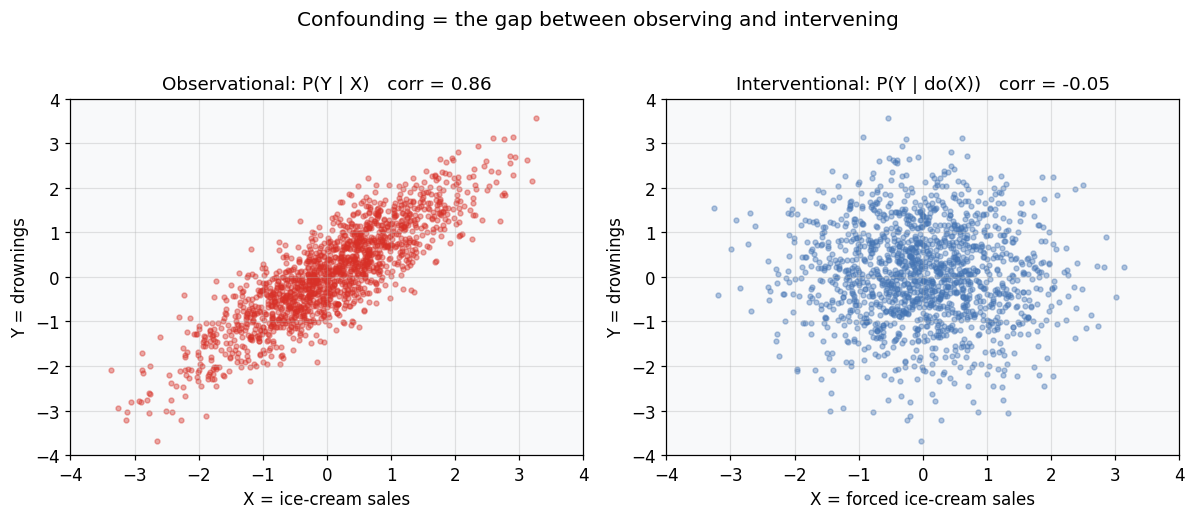

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
axes[0].scatter(X_obs, Y, s=10, c='#d73027', alpha=0.4)
axes[0].set_title(f'Observational: P(Y | X)   corr = {corr_obs:.2f}')
axes[0].set_xlabel('X = ice-cream sales'); axes[0].set_ylabel('Y = drownings')
axes[1].scatter(X_do, Y, s=10, c='#4575b4', alpha=0.4)
axes[1].set_title(f'Interventional: P(Y | do(X))   corr = {corr_do:.2f}')
axes[1].set_xlabel('X = forced ice-cream sales'); axes[1].set_ylabel('Y = drownings')
for ax in axes:
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
fig.suptitle('Confounding = the gap between observing and intervening', y=1.02)
plt.tight_layout(); plt.show()

### What you see

Left: observed $X$ and $Y$ form a clear positive band — correlation ≈ 0.8 — because both are children
of the confounder $C$. A naive reader concludes "ice cream causes drownings". Right: once we $do(X)$
(set sales by decree, severing the arrow from $C$ to $X$), the cloud goes round — correlation ≈ 0.
$X$ never caused $Y$.

This is the entire point of the do-operator: $P(Y\mid do(X)) \neq P(Y\mid X)$ whenever a confounder
is present, and **confounding is precisely that discrepancy**. Every probe lives on the left panel;
to earn a causal claim we must reach the right one.

## A latent model where one feature is encoded but unused

For the remaining experiments we need a representation we can intervene on. We build inputs with two
**independent** factors: **A**, which *determines the label* ($y=\mathbb{1}[A>0]$), and **B**, which
is irrelevant to the label. A model is trained with **two heads on a shared latent**: a *decoder*
(reconstruct the input — this forces the latent to retain B) and a *classifier* (predict $y$ — this
only needs A). The result: the latent encodes both A and B, but the classifier uses only A.

In [4]:
def make_data(n, seed):
    rng = np.random.RandomState(seed)
    A = rng.randn(n)                         # causal factor (label = sign(A))
    B = rng.randn(n)                         # independent, label-irrelevant factor
    other = rng.randn(n, 3)
    noise = rng.randn(n, 3) * 0.3
    x = np.column_stack([A, B, other, noise]).astype(np.float32)
    y = (A > 0).astype(np.int64)
    return x, y, A, B

X, y, A, B = make_data(4000, 0)

class AEClassifier(nn.Module):
    def __init__(self, d=8, h=16):
        super().__init__()
        self.enc = nn.Linear(d, h)
        self.dec = nn.Linear(h, d)           # reconstruction -> latent must retain B
        self.head = nn.Linear(h, 2)          # classification -> only needs A
    def encode(self, x):
        return torch.relu(self.enc(x))
    def forward(self, x):
        z = self.encode(x)
        return self.dec(z), self.head(z)

model = AEClassifier()
opt = torch.optim.Adam(model.parameters(), lr=5e-3)
mse, ce = nn.MSELoss(), nn.CrossEntropyLoss()
Xt, yt = torch.tensor(X), torch.tensor(y)
for _ in range(500):
    opt.zero_grad()
    xhat, logits = model(Xt)
    loss = mse(xhat, Xt) + ce(logits, yt)
    loss.backward(); opt.step()
clf_acc = (model(Xt)[1].argmax(1).numpy() == y).mean()
print(f'classifier accuracy: {clf_acc:.3f}')

def latent(x_np):
    with torch.no_grad():
        return model.encode(torch.tensor(x_np)).numpy()

def head_prob(z_np):
    with torch.no_grad():
        return torch.softmax(model.head(torch.tensor(np.asarray(z_np, np.float32))), 1).numpy()

def head_label(z_np):
    return head_prob(z_np).argmax(1)

Z = latent(X)
# probe directions for A and B (normal of a linear classifier reading each factor)
wA = LogisticRegression(max_iter=1000).fit(Z, (A > 0).astype(int)).coef_[0]; wA /= np.linalg.norm(wA)
wB = LogisticRegression(max_iter=1000).fit(Z, (B > 0).astype(int)).coef_[0]; wB /= np.linalg.norm(wB)
print('latent ready, probe directions wA, wB extracted')

classifier accuracy: 0.999
latent ready, probe directions wA, wB extracted


### What you see

The classifier hits ~1.0 (the label is just $\mathrm{sign}(A)$). Because the decoder must rebuild the
whole input from the latent, the 16-D representation $Z$ keeps **both** A and B — we recover a probe
direction $w_A$ and $w_B$ for each. This is the setup that lets the next experiment separate two
questions that probes alone conflate: *is the factor in the latent?* versus *does the classifier use
it?*

## Experiment 2: Decodable ≠ used

**Question:** If a probe reads a feature with high accuracy, does the model rely on it?

We measure two things for both A and B: **decodability** (probe accuracy from the latent) and
**causal effect** (how often the classifier's prediction flips when we *reflect* the factor's latent
component, $z \mapsto z - 2(w^\top z)\,w$ — a counterfactual $do$).

In [5]:
def decodability(target_bits):
    return LogisticRegression(max_iter=1000).fit(Z, target_bits).score(Z, target_bits)

def causal_effect(w):
    # reflect the component along w (counterfactual flip), measure label-change rate
    z_cf = Z - 2.0 * (Z @ w)[:, None] * w[None, :]
    return float((head_label(z_cf) != head_label(Z)).mean())

dec_A, dec_B = decodability((A > 0).astype(int)), decodability((B > 0).astype(int))
eff_A, eff_B = causal_effect(wA), causal_effect(wB)
print(f'A : decodability={dec_A:.3f}  causal effect={eff_A:.3f}')
print(f'B : decodability={dec_B:.3f}  causal effect={eff_B:.3f}')

A : decodability=0.998  causal effect=0.864
B : decodability=0.981  causal effect=0.024


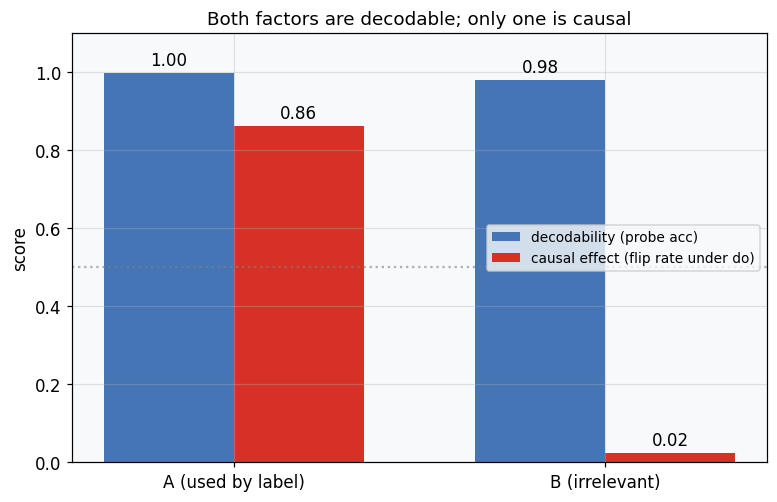

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 4.7))
x = np.arange(2); width = 0.35
ax.bar(x - width / 2, [dec_A, dec_B], width, label='decodability (probe acc)', color='#4575b4')
ax.bar(x + width / 2, [eff_A, eff_B], width, label='causal effect (flip rate under do)', color='#d73027')
for i, (d, e) in enumerate([(dec_A, eff_A), (dec_B, eff_B)]):
    ax.annotate(f'{d:.2f}', (i - width / 2, d), textcoords='offset points', xytext=(0, 5), ha='center')
    ax.annotate(f'{e:.2f}', (i + width / 2, e), textcoords='offset points', xytext=(0, 5), ha='center')
ax.axhline(0.5, color='gray', ls=':', alpha=0.6)
ax.set_xticks(x); ax.set_xticklabels(['A (used by label)', 'B (irrelevant)'])
ax.set_ylim(0, 1.1); ax.set_ylabel('score')
ax.set_title('Both factors are decodable; only one is causal')
ax.legend(fontsize=9, loc='center right')
plt.tight_layout(); plt.show()

### What you see

Both A and B are **highly decodable** (blue ≈ 1.0): the latent encodes them both, so a probe reads
either one easily. But the **causal effect** (red) splits them apart — reflecting A's latent component
flips the classifier's prediction for the large majority of inputs (~0.86), while reflecting B's
component changes almost nothing (~0.02). The classifier never used B.

This is the central lesson of the note made concrete: **a probe proves decodability, not usage.**
Reporting B's probe accuracy as evidence that "the model relies on B" would be flatly wrong — only the
intervention reveals the truth. This is why every earlier note ended with the same caveat.

## Experiment 3: The latent $do$-operator — erase and steer

**Question:** What does $z' = z - (w_C^\top z)\,w_C + v\,w_C$ actually do to the output?

This single formula is the $do$-operator on a latent: subtract the current component along the concept
direction, then add back a *forced* value $v$. Setting $v=0$ **erases** the concept; varying $v$
**steers** it. We sweep $v$ along the causal direction $w_A$ and read the classifier's response.

In [7]:
def intervene(Zin, w, v):
    return Zin - (Zin @ w)[:, None] * w[None, :] + v * w[None, :]

vs = np.linspace(-3, 3, 31)
resp_A = [head_prob(intervene(Z, wA, v))[:, 1].mean() for v in vs]   # steer the causal direction
resp_B = [head_prob(intervene(Z, wB, v))[:, 1].mean() for v in vs]   # steer the irrelevant direction
erase_A = head_prob(intervene(Z, wA, 0.0))[:, 1]                     # do(A := 0): erase
print(f'do(A:=0) mean P(y=1) = {erase_A.mean():.3f}  (cause removed -> collapses to default class)')

do(A:=0) mean P(y=1) = 0.027  (cause removed -> collapses to default class)


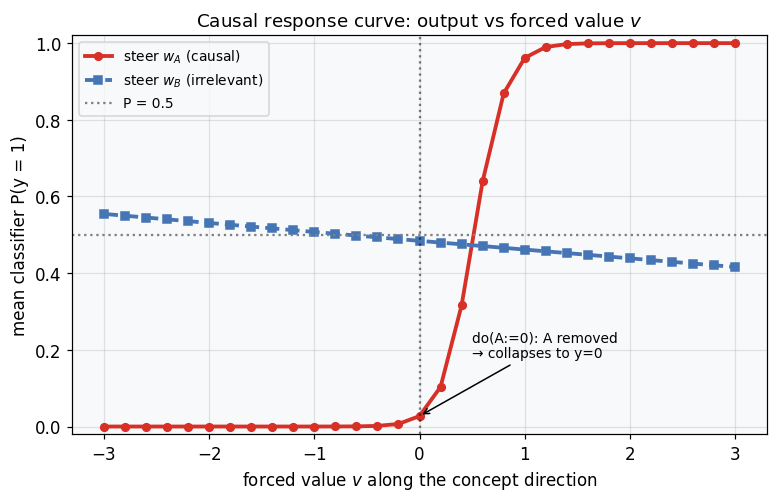

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 4.7))
ax.plot(vs, resp_A, 'o-', color='#d73027', lw=2.5, ms=5, label='steer $w_A$ (causal)')
ax.plot(vs, resp_B, 's--', color='#4575b4', lw=2.5, ms=5, label='steer $w_B$ (irrelevant)')
ax.axhline(0.5, color='gray', ls=':', label='P = 0.5')
ax.axvline(0, color='k', ls=':', alpha=0.5)
ax.annotate('do(A:=0): A removed\n→ collapses to y=0', xy=(0, resp_A[len(resp_A) // 2]),
            xytext=(0.5, 0.18), arrowprops=dict(arrowstyle='->'), fontsize=9)
ax.set_title('Causal response curve: output vs forced value $v$')
ax.set_xlabel('forced value $v$ along the concept direction')
ax.set_ylabel('mean classifier P(y = 1)')
ax.set_ylim(-0.02, 1.02); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### What you see

Steering the **causal** direction $w_A$ (red) sweeps the classifier from confidently $y=0$ to
confidently $y=1$ as $v$ goes negative→positive — a clean monotone *causal response curve*. Note the
curve crosses 0.5 at the model's *learned threshold*, not at $v=0$: setting $v=0$ ($do(A:=0)$) strips
A's evidence and the classifier collapses to its default class ($y=0$) — which is exactly why
main-task accuracy falls to chance in the next experiment. Steering the **irrelevant** direction
$w_B$ (blue) is a flat line at 0.5: forcing B to any value does nothing.

The same one-line surgery thus serves both roles in the note's taxonomy — **erasure** ($v=0$) and
**counterfactual steering** ($v\neq0$) — and the shape of the curve *is* the causal effect. This is
the operator Layer B will expose as `LatentSpace.intervene`.

## Experiment 4: Amnesic probing — erase, then watch behaviour

**Question:** How do we test usage at the level of a whole concept subspace, not one direction?

Amnesic Probing (Elazar et al., 2021) erases a concept from the representation with **INLP**
(iterative nullspace projection: fit a linear probe, project its direction out, repeat) and measures
how far the main-task accuracy drops. A used concept → big drop; a merely-decodable one → no drop.

In [9]:
def inlp_projection(Zin, target_bits, n_iter=8):
    P = np.eye(Zin.shape[1])
    Zc = Zin.copy()
    for _ in range(n_iter):
        clf = LogisticRegression(max_iter=1000).fit(Zc, target_bits)
        w = clf.coef_[0]; w /= np.linalg.norm(w)
        Pw = np.eye(len(w)) - np.outer(w, w)   # project OUT direction w
        Zc = Zc @ Pw
        P = P @ Pw
    return P

base_acc = (head_label(Z) == y).mean()
P_A = inlp_projection(Z, (A > 0).astype(int))
P_B = inlp_projection(Z, (B > 0).astype(int))
acc_erase_A = (head_label(Z @ P_A) == y).mean()
acc_erase_B = (head_label(Z @ P_B) == y).mean()
print(f'baseline accuracy        = {base_acc:.3f}')
print(f'after erasing A (used)   = {acc_erase_A:.3f}')
print(f'after erasing B (unused) = {acc_erase_B:.3f}')

baseline accuracy        = 0.999
after erasing A (used)   = 0.512
after erasing B (unused) = 0.937


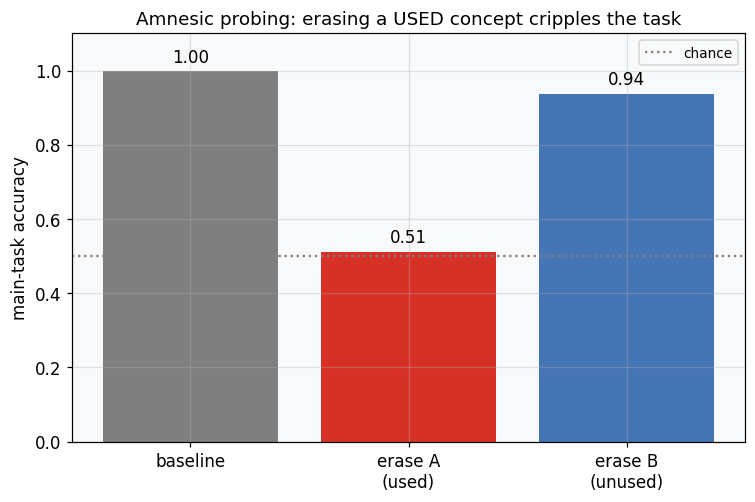

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.7))
labels = ['baseline', 'erase A\n(used)', 'erase B\n(unused)']
vals = [base_acc, acc_erase_A, acc_erase_B]
colors = ['#7f7f7f', '#d73027', '#4575b4']
ax.bar(labels, vals, color=colors)
for i, v in enumerate(vals):
    ax.annotate(f'{v:.2f}', (i, v), textcoords='offset points', xytext=(0, 6), ha='center')
ax.axhline(0.5, color='gray', ls=':', label='chance')
ax.set_ylim(0, 1.1); ax.set_ylabel('main-task accuracy')
ax.set_title('Amnesic probing: erasing a USED concept cripples the task')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### What you see

Erasing A's linear subspace (red) collapses the classifier to chance (~0.5): the task literally cannot
be solved once its cause is gone — proof the model *used* A. Erasing B's subspace (blue) barely dents
accuracy (~0.94): removing a decodable-but-unused feature costs almost nothing.

This is the behavioural logic of amnesic probing — *the utility of a property is the damage done by
removing it*. It upgrades a correlational probe into a causal test, and it reuses the very same
subspace-projection machinery as
[subspace projection](../../04-latent-computation/research/04-subspace-projection.md).

## Experiment 5 (limitation): off-manifold interventions are artifacts

**Question:** Can we trust the output of *any* intervention, however large?

Forcing $v$ far beyond the values the encoder ever produces pushes $z'$ **off the data manifold** —
into a region the model never saw. The classifier still returns *something*, but that something is a
property of garbage input, not a causal fact. We track the output alongside the **Mahalanobis
distance** of $z'$ to the training-latent distribution.

In [11]:
mu = Z.mean(0)
cov = np.cov(Z, rowvar=False) + 1e-4 * np.eye(Z.shape[1])
cov_inv = np.linalg.inv(cov)

def mahalanobis(zrow):
    d = zrow - mu
    return np.sqrt(np.einsum('ij,jk,ik->i', d, cov_inv, d))

# typical in-distribution spread of the A-component, for reference
indist = np.abs(Z @ wA)
v_grid = np.linspace(0, 15, 31)
z0 = Z[:200]                                  # a batch of real latents to push
out, mdist = [], []
for v in v_grid:
    zp = intervene(z0, wA, v)
    out.append(head_prob(zp)[:, 1].mean())
    mdist.append(mahalanobis(zp).mean())
typical = np.percentile(indist, 99)
print(f'99th-percentile in-distribution |wA . z| = {typical:.2f}')

99th-percentile in-distribution |wA . z| = 6.56


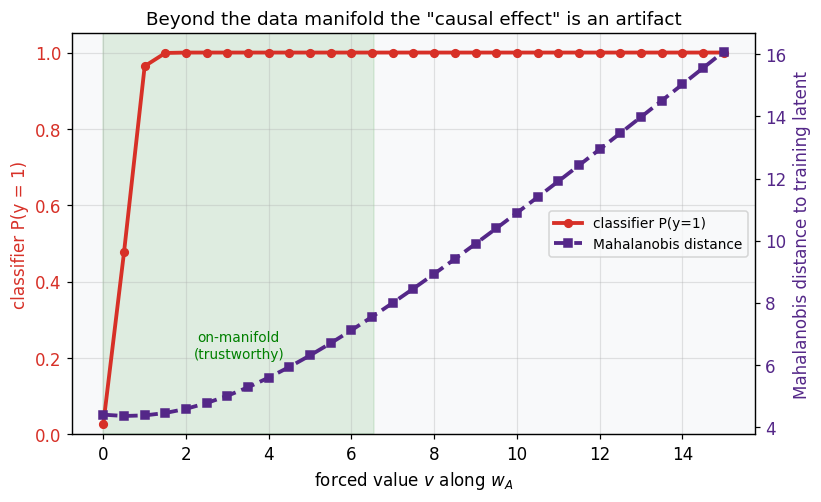

In [12]:
fig, ax1 = plt.subplots(figsize=(7.6, 4.7))
ax1.plot(v_grid, out, 'o-', color='#d73027', lw=2.5, ms=5, label='classifier P(y=1)')
ax1.set_xlabel('forced value $v$ along $w_A$')
ax1.set_ylabel('classifier P(y = 1)', color='#d73027')
ax1.tick_params(axis='y', labelcolor='#d73027'); ax1.set_ylim(0, 1.05)
ax2 = ax1.twinx()
ax2.plot(v_grid, mdist, 's--', color='#542788', lw=2.5, ms=5, label='Mahalanobis distance')
ax2.set_ylabel('Mahalanobis distance to training latent', color='#542788')
ax2.tick_params(axis='y', labelcolor='#542788'); ax2.grid(False)
ax1.axvspan(0, typical, color='green', alpha=0.10)
ax1.annotate('on-manifold\n(trustworthy)', xy=(typical / 2, 0.2), ha='center', fontsize=9, color='green')
ax1.set_title('Beyond the data manifold the "causal effect" is an artifact')
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='center right', fontsize=9)
plt.tight_layout(); plt.show()

### What you see

Inside the green band — values of $v$ the encoder actually produces — the output responds smoothly and
the Mahalanobis distance stays small: the intervention is **on-manifold** and its effect is a real
causal signal. Push further and the output keeps drifting (often saturating), but the Mahalanobis
distance climbs without bound: $z'$ is now a point no real input ever maps to, so the classifier's
response is a property of *off-manifold garbage*, not of the concept.

The lesson: an intervention is only as trustworthy as its **proximity to the data manifold**. This is
why `LatentSpace.causal_effect` should gate its result with a
[Mahalanobis](../../04-latent-computation/research/05-mahalanobis-distance.md) check and
refuse to report effects measured far off-manifold — the boundary that keeps causal claims honest.

## Summary / Key Takeaways

- **Exp 1** — Confounding is the gap $P(Y\mid X)\neq P(Y\mid do(X))$: a strong observed correlation
  can vanish entirely under intervention.
- **Exp 2** — **Decodable ≠ used**: a feature can be read off the latent with ~100% probe accuracy yet
  have zero causal effect on the output.
- **Exp 3** — The latent $do$-operator $z'=z-(w^\top z)w+vw$ both **erases** ($v=0$) and **steers**
  ($v\neq0$); the response curve *is* the causal effect.
- **Exp 4** — **Amnesic probing**: erasing a used concept's subspace crashes the task to chance, while
  erasing a decodable-but-unused one costs nothing — a causal test, not a correlational one.
- **Exp 5** — Interventions are only valid **on-manifold**; pushed too far they produce artifacts, so
  gate causal claims with a distance-to-manifold check.
